# 01 — Análisis Exploratorio de Datos (EDA)

**Proyecto**: CostForecast AI — Prueba técnica DataKnow  
**Autor**: Santiago Rueda  
**Objetivo**: Entender la naturaleza de los datos, identificar qué materias primas explican el comportamiento de los equipos, y generar hipótesis para el modelado.

## Índice

1. Carga y consolidación de fuentes
2. Auditoría de calidad
3. Análisis univariado (distribuciones, tendencias)
4. Análisis bivariado (correlaciones, scatter plots)
5. Análisis temporal (estacionariedad, autocorrelación)
6. Análisis de lags cruzados
7. Causalidad de Granger
8. Conclusiones y siguiente paso

## 0. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

# Importar el paquete local
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from costforecast.data.consolidator import build_consolidated_dataset
from costforecast.data.quality import assess_quality

# Configuración de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## 1. Carga y consolidación

In [2]:
DATA_DIR = Path.cwd().parent / 'data' / 'raw'

df = build_consolidated_dataset(
    historico_path=DATA_DIR / 'historico_equipos.csv',
    x_path=DATA_DIR / 'X.csv',
    y_path=DATA_DIR / 'Y.csv',
    z_path=DATA_DIR / 'Z.csv',
    prefer_raw_series=False,  # Usar el histórico consolidado
)

print(f'Shape: {df.shape}')
print(f'Rango: {df.index.min().date()} → {df.index.max().date()}')
df.head()

2026-04-17 10:07:33 | INFO     | costforecast.data.consolidator:load_historico_equipos:29 - Cargando historico_equipos desde C:\Users\analistapowerbi\Documents\GitHub\cost-forecast\costforecast-ai\data\raw\historico_equipos.csv


2026-04-17 10:07:33 | INFO     | costforecast.data.consolidator:load_historico_equipos:33 -   → 3530 filas, 5 columnas


2026-04-17 10:07:33 | INFO     | costforecast.data.consolidator:build_consolidated_dataset:105 - Usando precios consolidados de historico_equipos (modo default)


Shape: (3530, 5)
Rango: 2010-01-04 → 2023-08-31


,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Date,,,,,
2010-01-04,80.12,527.50,2225.25,434.73,931.73
2010-01-05,80.59,527.50,2246.50,449.97,968.56
2010-01-06,81.89,527.50,2302.50,444.48,960.51
2010-01-07,81.51,527.50,2306.50,440.90,960.14
2010-01-08,81.37,552.50,2261.25,448.82,949.55


## 2. Auditoría de calidad

Usamos el módulo `data.quality` desarrollado en `src/` para generar un reporte reproducible.

In [3]:
report = assess_quality(
    df=df,
    value_columns=list(df.columns),
    frequency='B (business daily)',
    run_stationarity=True,
)

print(report.to_markdown())

2026-04-17 10:07:33 | INFO     | costforecast.data.quality:assess_quality:155 - Ejecutando auditoría de calidad sobre 5 columnas


2026-04-17 10:07:34 | INFO     | costforecast.data.quality:assess_quality:196 - Auditoría completada


# Auditoría de calidad del dataset

## Dimensiones

- **Filas**: 3,530
- **Columnas**: 5
- **Rango temporal**: 2010-01-04 → 2023-08-31
- **Frecuencia detectada**: B (business daily)
- **Fechas duplicadas**: 0
- **Gaps en serie temporal**: 34

## Valores faltantes

| Columna | Nulos | % |
|---|---|---|
| Price_X | 0 | 0.00% |
| Price_Y | 0 | 0.00% |
| Price_Z | 0 | 0.00% |
| Price_Equipo1 | 0 | 0.00% |
| Price_Equipo2 | 0 | 0.00% |

## Outliers detectados

| Columna | IQR (1.5×) | Z-score (>3σ) |
|---|---|---|
| Price_X | 0 | 0 |
| Price_Y | 291 | 8 |
| Price_Z | 90 | 56 |
| Price_Equipo1 | 223 | 7 |
| Price_Equipo2 | 105 | 45 |

## Estacionariedad (Augmented Dickey-Fuller)

| Columna | ADF statistic | p-value | Estacionaria? |
|---|---|---|---|
| Price_X | -1.7052 | 0.4284 | ✗ No |
| Price_Y | -2.5301 | 0.1083 | ✗ No |
| Price_Z | -2.2029 | 0.2052 | ✗ No |
| Price_Equipo1 | -2.3903 | 0.1445 | ✗ No |
| Price_Equipo2 | -1.9064 | 0.3290 | ✗ No |

## Estadísticas descriptivas

|           

**Hallazgos esperados**:
- Series NO estacionarias (típico de precios) → requerirán diferenciación para SARIMAX.
- Pueden existir gaps en días hábiles (feriados).
- Outliers moderados son esperables (shocks de mercado).

## 3. Análisis univariado

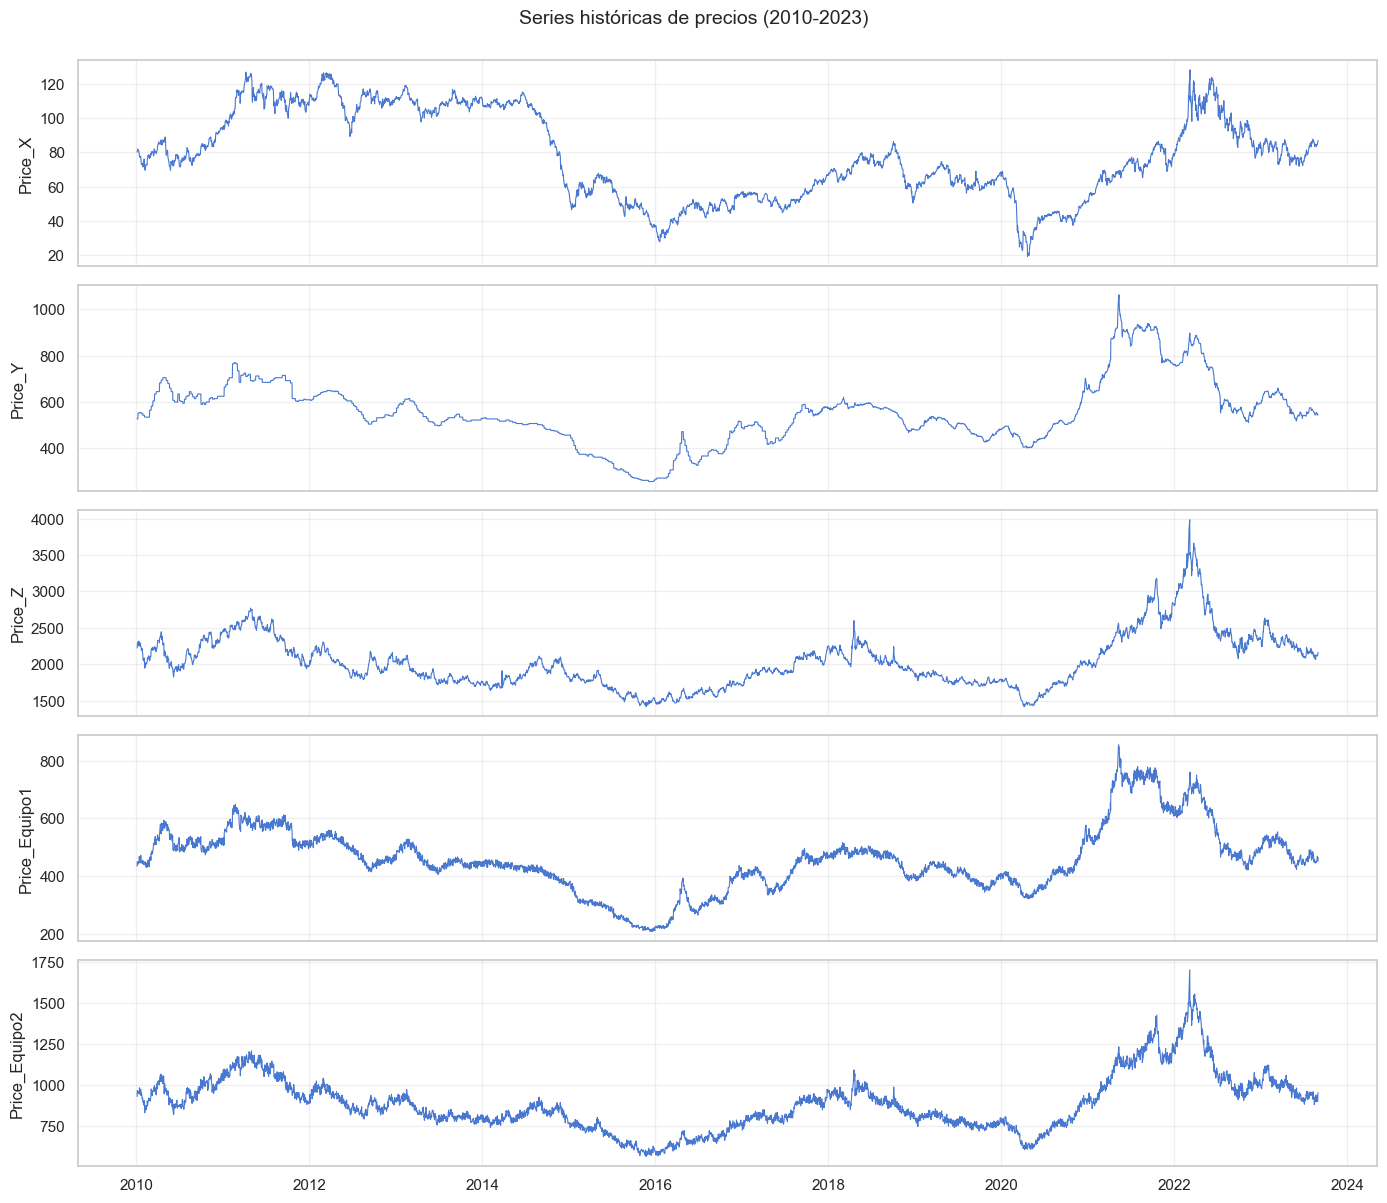

In [4]:
# Series temporales
fig, axes = plt.subplots(nrows=len(df.columns), ncols=1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col], linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)
plt.suptitle('Series históricas de precios (2010-2023)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

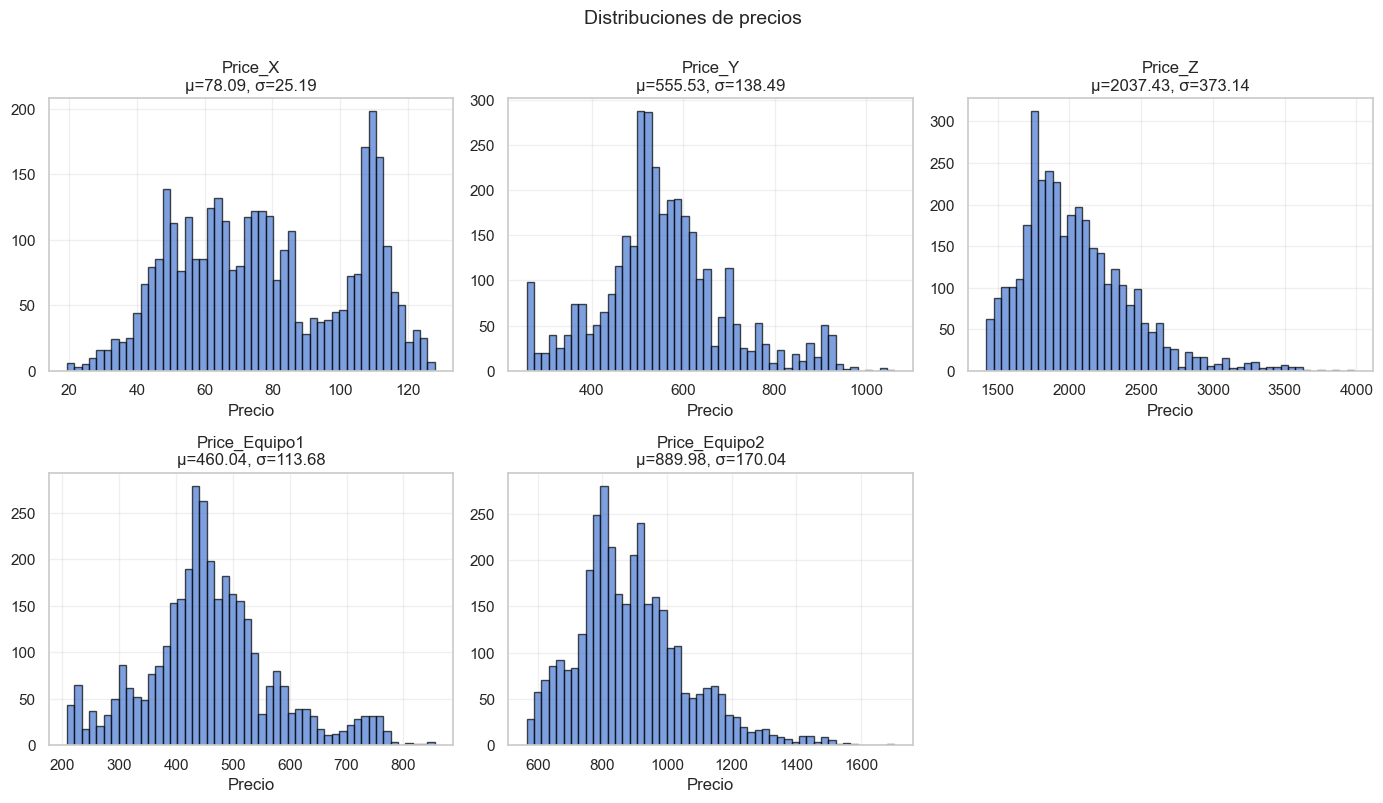

In [5]:
# Distribuciones
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
for ax, col in zip(axes.flat, df.columns):
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}\nμ={df[col].mean():.2f}, σ={df[col].std():.2f}')
    ax.set_xlabel('Precio')
    ax.grid(alpha=0.3)
# Eliminar el 6to subplot (solo hay 5 series)
if len(df.columns) < 6:
    axes.flat[-1].axis('off')
plt.suptitle('Distribuciones de precios', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 4. Análisis bivariado

### 4.1. Matriz de correlación

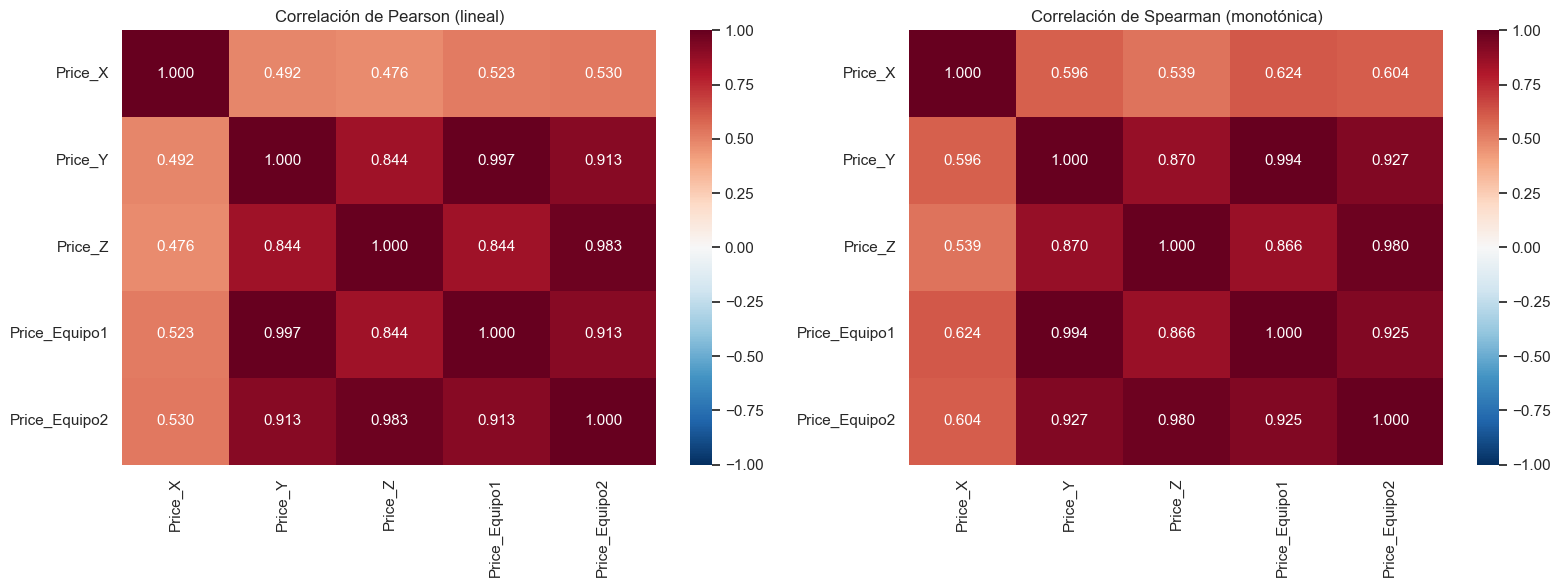

In [6]:
pearson = df.corr(method='pearson')
spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.3f', ax=axes[0])
axes[0].set_title('Correlación de Pearson (lineal)')
sns.heatmap(spearman, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.3f', ax=axes[1])
axes[1].set_title('Correlación de Spearman (monotónica)')
plt.tight_layout()
plt.show()

### 4.2. Ranking de correlaciones con los equipos

In [7]:
materias_primas = ['Price_X', 'Price_Y', 'Price_Z']
equipos = ['Price_Equipo1', 'Price_Equipo2']

print('=' * 60)
print('CORRELACIÓN EQUIPOS vs MATERIAS PRIMAS')
print('=' * 60)
for eq in equipos:
    print(f'\n{eq}:')
    for mp in materias_primas:
        p = df[eq].corr(df[mp], method='pearson')
        s = df[eq].corr(df[mp], method='spearman')
        print(f'  vs {mp}: Pearson={p:+.4f}  Spearman={s:+.4f}')

CORRELACIÓN EQUIPOS vs MATERIAS PRIMAS

Price_Equipo1:
  vs Price_X: Pearson=+0.5234  Spearman=+0.6241
  vs Price_Y: Pearson=+0.9966  Spearman=+0.9942
  vs Price_Z: Pearson=+0.8440  Spearman=+0.8663

Price_Equipo2:
  vs Price_X: Pearson=+0.5303  Spearman=+0.6037
  vs Price_Y: Pearson=+0.9127  Spearman=+0.9271
  vs Price_Z: Pearson=+0.9827  Spearman=+0.9797


### 4.3. Scatter plots con línea de regresión

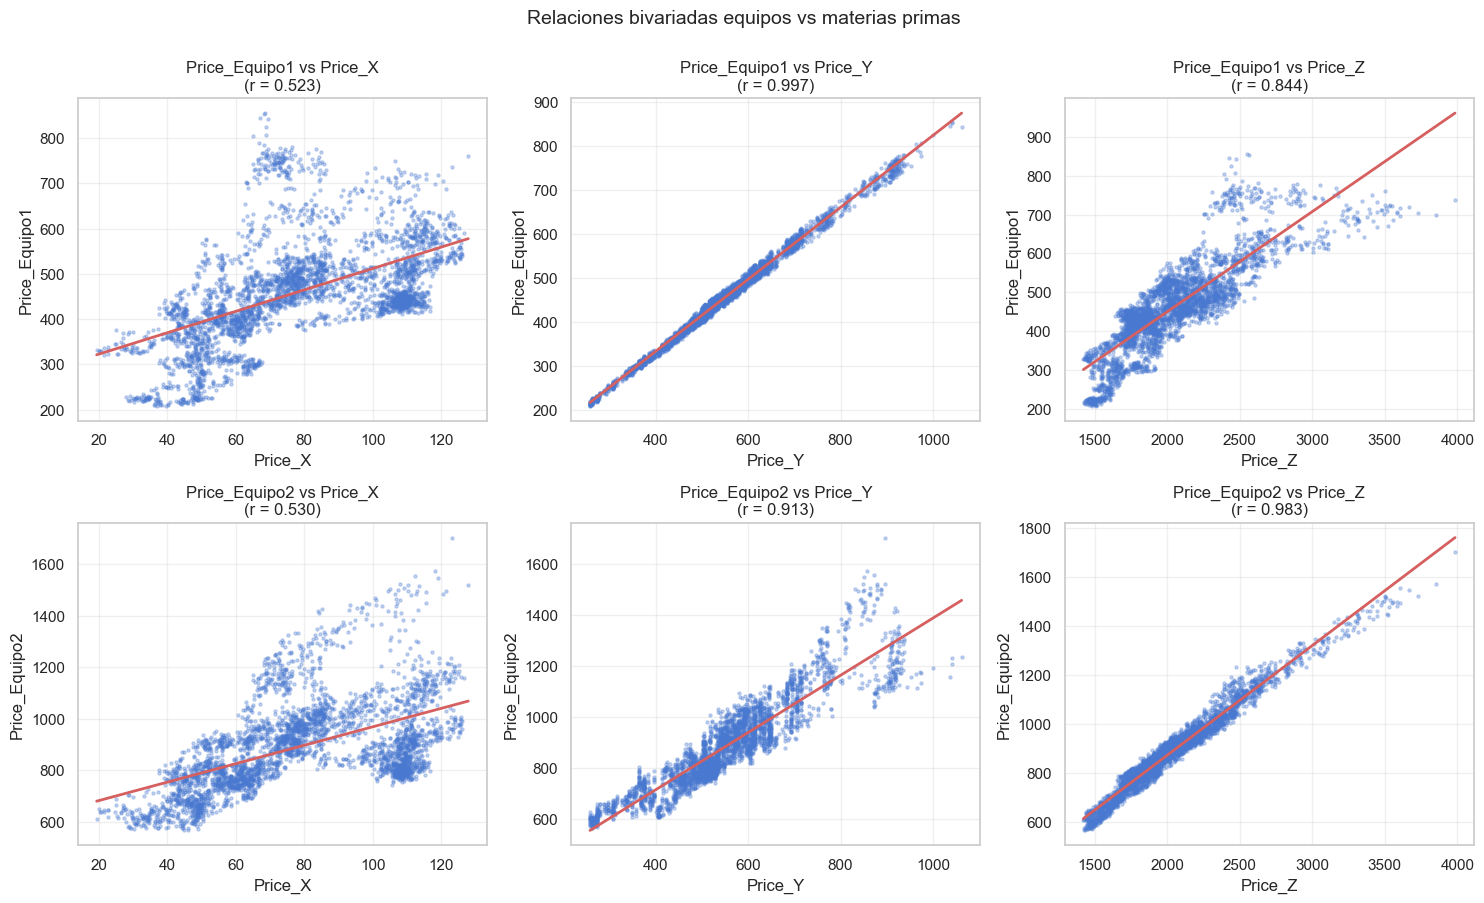

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, eq in enumerate(equipos):
    for j, mp in enumerate(materias_primas):
        ax = axes[i, j]
        ax.scatter(df[mp], df[eq], alpha=0.3, s=5)
        # Regresión lineal simple
        z = np.polyfit(df[mp], df[eq], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[mp].min(), df[mp].max(), 100)
        ax.plot(x_line, p(x_line), 'r-', linewidth=2)
        corr = df[mp].corr(df[eq])
        ax.set_title(f'{eq} vs {mp}\n(r = {corr:.3f})')
        ax.set_xlabel(mp)
        ax.set_ylabel(eq)
        ax.grid(alpha=0.3)
plt.suptitle('Relaciones bivariadas equipos vs materias primas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 5. Análisis temporal — estacionariedad

Los modelos como SARIMAX requieren series estacionarias. Revisamos el test ADF y aplicamos diferenciación si es necesario.

In [9]:
print('=' * 70)
print('TEST ADF — Series originales')
print('=' * 70)
for col in df.columns:
    result = adfuller(df[col].dropna(), autolag='AIC')
    is_stat = 'ESTACIONARIA' if result[1] < 0.05 else 'NO estacionaria'
    print(f'{col:20s}  ADF={result[0]:8.4f}  p-value={result[1]:.4f}  → {is_stat}')

print()
print('=' * 70)
print('TEST ADF — Primera diferencia')
print('=' * 70)
df_diff = df.diff().dropna()
for col in df_diff.columns:
    result = adfuller(df_diff[col].dropna(), autolag='AIC')
    is_stat = 'ESTACIONARIA' if result[1] < 0.05 else 'NO estacionaria'
    print(f'{col:20s}  ADF={result[0]:8.4f}  p-value={result[1]:.4f}  → {is_stat}')

TEST ADF — Series originales
Price_X               ADF= -1.7052  p-value=0.4284  → NO estacionaria


Price_Y               ADF= -2.5301  p-value=0.1083  → NO estacionaria
Price_Z               ADF= -2.2029  p-value=0.2052  → NO estacionaria
Price_Equipo1         ADF= -2.3903  p-value=0.1445  → NO estacionaria


Price_Equipo2         ADF= -1.9064  p-value=0.3290  → NO estacionaria

TEST ADF — Primera diferencia
Price_X               ADF=-27.4546  p-value=0.0000  → ESTACIONARIA
Price_Y               ADF= -8.7266  p-value=0.0000  → ESTACIONARIA


Price_Z               ADF=-14.7240  p-value=0.0000  → ESTACIONARIA
Price_Equipo1         ADF=-16.9462  p-value=0.0000  → ESTACIONARIA
Price_Equipo2         ADF=-29.7067  p-value=0.0000  → ESTACIONARIA


## 6. Análisis de lags cruzados

¿La materia prima X predice al equipo con algún retraso? Esto es crítico para saber si podemos usarla como feature con lag en el modelo.

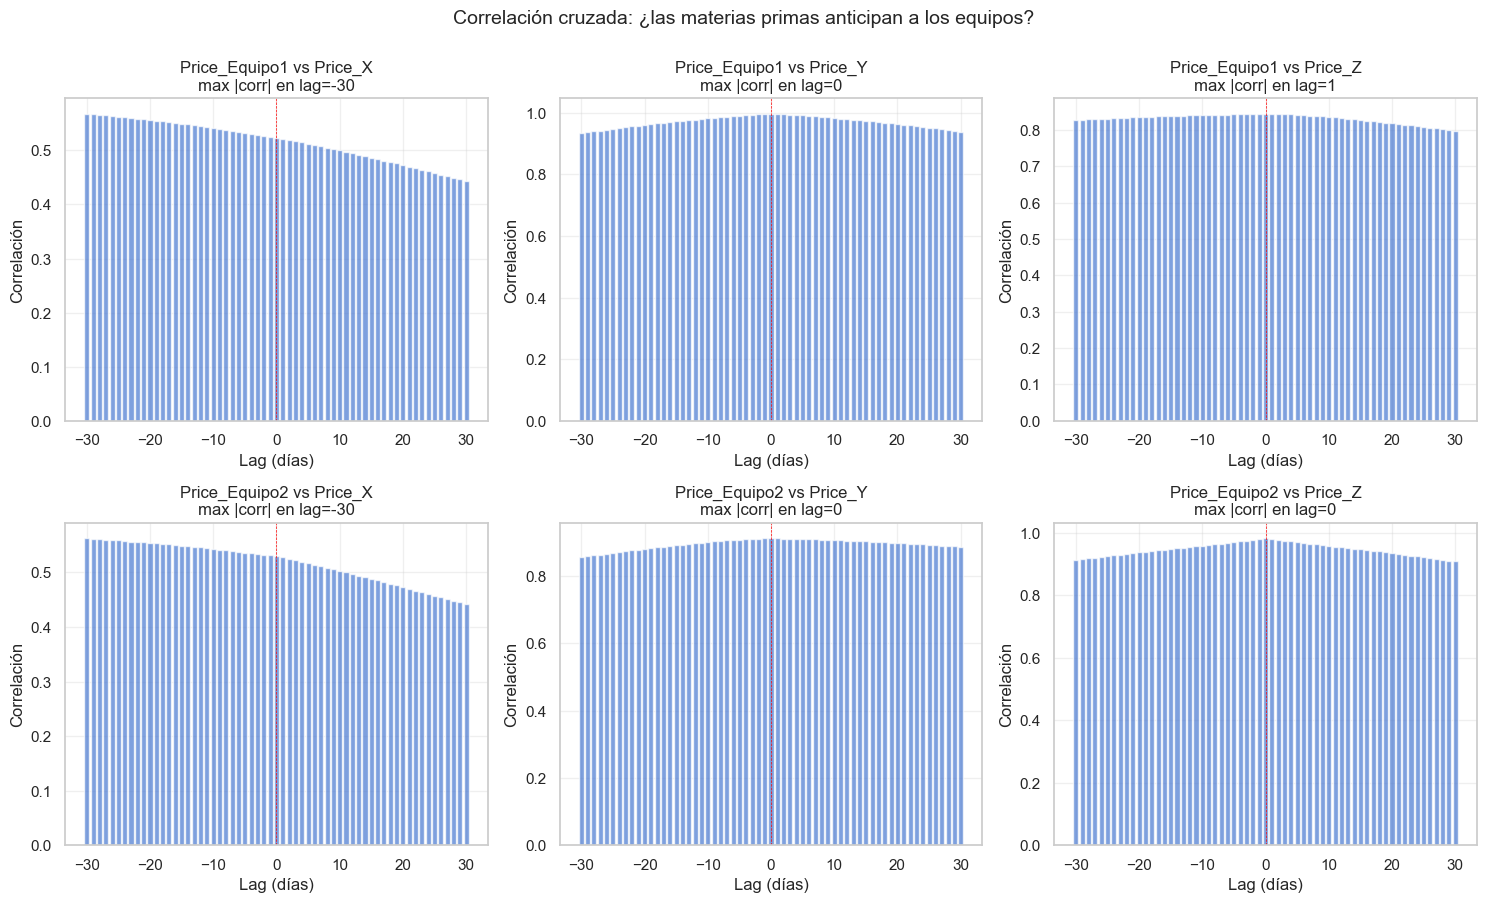

In [10]:
def cross_correlation(x, y, max_lag=30):
    '''Correlación cruzada para distintos lags (de X adelantado respecto a Y).'''
    return [x.shift(lag).corr(y) for lag in range(-max_lag, max_lag + 1)]

MAX_LAG = 30  # 30 días hábiles ~ 6 semanas
lags = list(range(-MAX_LAG, MAX_LAG + 1))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, eq in enumerate(equipos):
    for j, mp in enumerate(materias_primas):
        ax = axes[i, j]
        ccf = cross_correlation(df[mp], df[eq], MAX_LAG)
        ax.bar(lags, ccf, alpha=0.7)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(0, color='red', linewidth=0.5, linestyle='--')
        max_lag_idx = np.argmax(np.abs(ccf))
        ax.set_title(f'{eq} vs {mp}\nmax |corr| en lag={lags[max_lag_idx]}')
        ax.set_xlabel('Lag (días)')
        ax.set_ylabel('Correlación')
        ax.grid(alpha=0.3)
plt.suptitle('Correlación cruzada: ¿las materias primas anticipan a los equipos?', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 7. Causalidad de Granger

¿Los valores pasados de la materia prima ayudan a predecir el equipo, más allá de los propios valores pasados del equipo?

**H0**: la serie X no causa en sentido de Granger a la serie Y (i.e., conocer pasados de X no mejora predicción de Y).

Un **p-value < 0.05** rechaza H0 → existe causalidad de Granger.

In [11]:
MAX_LAGS_GRANGER = 5  # probar hasta 5 días de lag

print('=' * 70)
print('CAUSALIDAD DE GRANGER — ¿Materia prima → Equipo?')
print('=' * 70)

# Usar primera diferencia (series estacionarias)
df_d = df.diff().dropna()

resultados = []
for eq in equipos:
    for mp in materias_primas:
        # grangercausalitytests espera [Y, X] (Y es la variable predicha)
        pair = df_d[[eq, mp]].dropna()
        try:
            res = grangercausalitytests(pair, maxlag=MAX_LAGS_GRANGER, verbose=False)
            # Tomar el menor p-value a través de los lags
            p_values = [res[lag][0]['ssr_ftest'][1] for lag in range(1, MAX_LAGS_GRANGER + 1)]
            min_p = min(p_values)
            best_lag = p_values.index(min_p) + 1
            causa = 'SÍ' if min_p < 0.05 else 'NO'
            resultados.append({
                'Predictor': mp,
                'Target': eq,
                'min_p_value': min_p,
                'best_lag': best_lag,
                'Causa_Granger': causa,
            })
        except Exception as e:
            print(f'Error en {mp} → {eq}: {e}')

granger_df = pd.DataFrame(resultados)
print(granger_df.to_string(index=False))

CAUSALIDAD DE GRANGER — ¿Materia prima → Equipo?
Predictor        Target  min_p_value  best_lag Causa_Granger
  Price_X Price_Equipo1         0.00         4            SÍ
  Price_Y Price_Equipo1         0.00         5            SÍ
  Price_Z Price_Equipo1         0.00         4            SÍ
  Price_X Price_Equipo2         0.00         4            SÍ
  Price_Y Price_Equipo2         0.00         4            SÍ
  Price_Z Price_Equipo2         0.00         5            SÍ


C:\Users\analistapowerbi\Documents\GitHub\cost-forecast\costforecast-ai\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\analistapowerbi\Documents\GitHub\cost-forecast\costforecast-ai\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\analistapowerbi\Documents\GitHub\cost-forecast\costforecast-ai\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\analistapowerbi\Documents\GitHub\cost-forecast\costforecast-ai\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\analistapowerbi\Documents\GitHub\cost-forecast\costforecast-ai\.venv\Lib\site-packages\

## 8. Conclusiones del EDA

*Esta celda se debe completar después de revisar los resultados anteriores.*

**Variables seleccionadas para el modelado**:
- Equipo 1: [a determinar con base en Granger + correlación]
- Equipo 2: [a determinar]

**Decisiones clave**:
- Transformación: diferenciación simple (las series son I(1))
- Horizonte de predicción propuesto: [N días, justificado por degradación del MAPE en backtesting]
- Modelos candidatos: SARIMAX con variables exógenas, XGBoost con lags

**Siguiente notebook**: `02_feature_engineering.ipynb`